# Global Spatial IKE Climatology

Two-panel map: a) global tropical cyclone track density, b) spatial distribution
of mean IKE. Storms are grouped by IBTrACS's own genesis-basin-code label,
same as the interannual and SSHWS figures. 

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import os

import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter

from ike_climatology import config
from ike_climatology.ibtracs_io import load_master_dataframe


## Data extraction

`load_master_dataframe` handles the per-basin, per-storm loop: temporal + synoptic-hour
filtering, genesis-basin-code check (`prepare_ibtracs_storm`), then IKE calculation
(`calculate_storm_metrics`).

In [3]:
master_df = load_master_dataframe(
    basins=config.BASINS_TO_ANALYZE,
    file_map=config.IBTRACS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
    drop_non_tropical_phases=True,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH.")

print(f"{len(master_df)} timesteps across {master_df['storm_id'].nunique()} storms.")


--- Starting Initial Data Loading and Processing for All Basins ---
    - Loading IBTrACS data for North Atlantic (2004-2024)
        Found 380 storms in file.
        - Filtered out 2 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for East Pacific (2004-2024)
        Found 497 storms in file.
        - Filtered out 79 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for West Pacific (2004-2024)
        Found 622 storms in file.
        - Filtered out 16 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for North Indian (2004-2024)
        Found 220 storms in file.
        - Filtered out 13 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for South Indian (2004-2024)
        Found 367 storms in file.
        - Filtered out 22 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data

## Figure: 2-panel global climatology

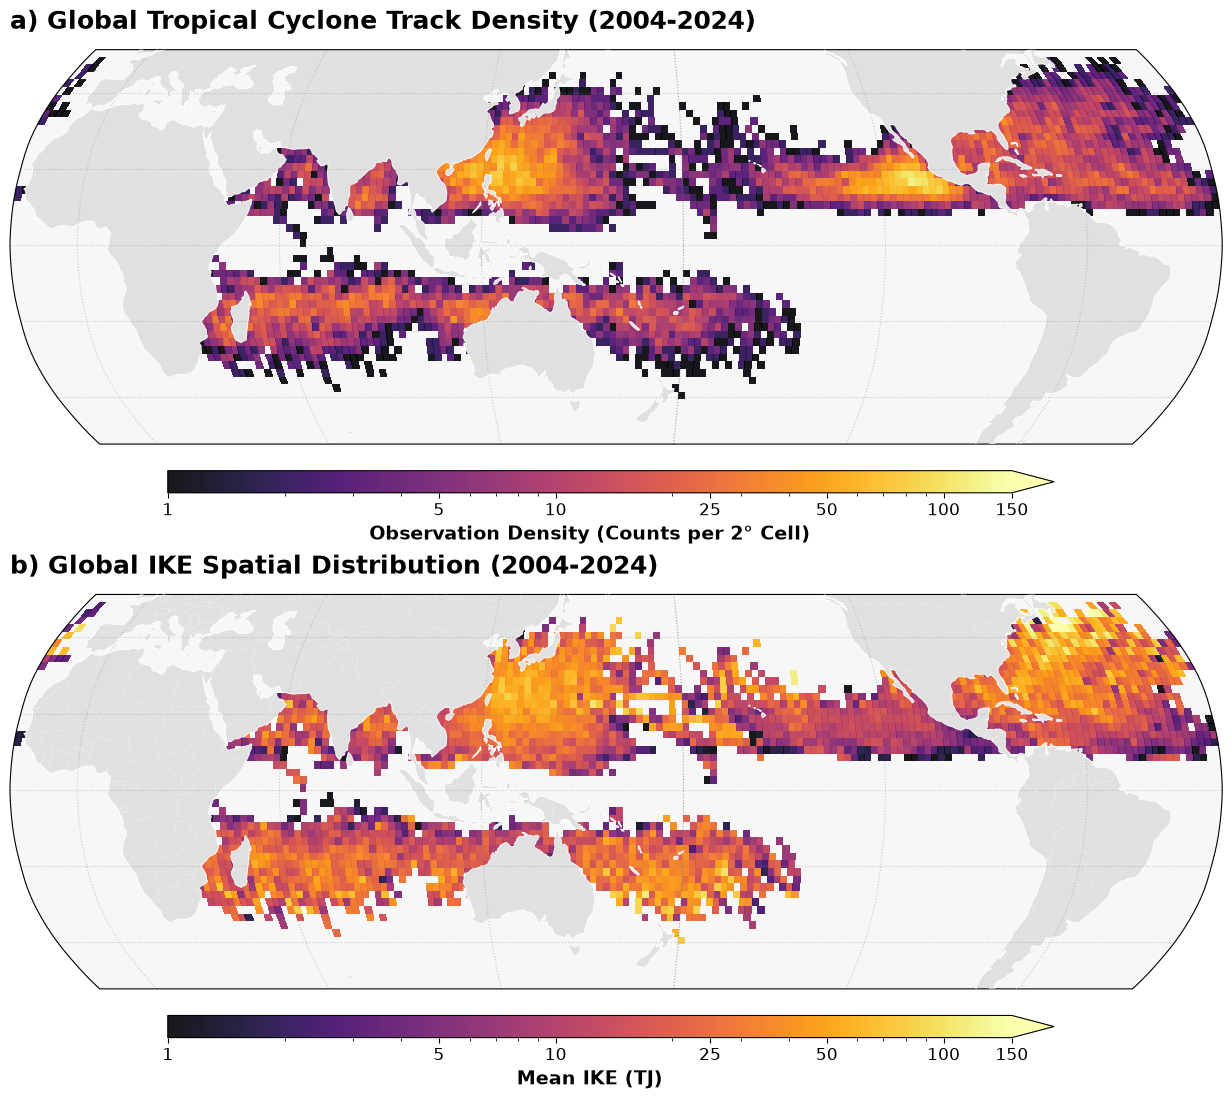

In [4]:
df_map = master_df.dropna(subset=["storm_lon_deg", "storm_lat_deg", "total_ike_tj"]).copy()
df_map["lon_360"] = df_map["storm_lon_deg"] % 360

lon_bins = np.arange(0, 360.5, 2)
lat_bins = np.arange(-52.5, 52.5, 2)

lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_mesh, lat_mesh = np.meshgrid(lon_centers, lat_centers)

years_str = f"({master_df['storm_year'].min()}-{master_df['storm_year'].max()})"

fig, axes = plt.subplots(
    2, 1, figsize=(16, 11),
    subplot_kw={"projection": ccrs.Robinson(central_longitude=160)},
)

ocean_feat = cfeature.OCEAN.with_scale("110m")
land_feat = cfeature.LAND.with_scale("110m")

# --- Panel A: Track Density ------------------------------------------------
ax0 = axes[0]

counts, _, _ = np.histogram2d(df_map["lon_360"], df_map["storm_lat_deg"], bins=[lon_bins, lat_bins])
counts[counts < 0.5] = np.nan  # mask empty cells

ax0.set_facecolor("#f7f7f7")
ax0.add_feature(land_feat, facecolor="#e0e0e0", zorder=2)
ax0.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="white", zorder=3)

pm0 = ax0.pcolormesh(
    lon_mesh, lat_mesh, counts.T,
    cmap="inferno", norm=LogNorm(vmin=1, vmax=150),
    transform=ccrs.PlateCarree(), zorder=1, alpha=0.9,
)

cb0 = fig.colorbar(pm0, ax=ax0, orientation="horizontal", pad=0.06, shrink=0.7,
                    aspect=40, fraction=0.05, extend="max")
cb0.set_label("Observation Density (Counts per 2\u00b0 Cell)", size=14, weight="bold")
cb0.ax.xaxis.set_major_formatter(ScalarFormatter())
cb0.set_ticks([1, 5, 10, 25, 50, 100, 150])
cb0.ax.tick_params(labelsize=12)

ax0.set_title(f"a) Global Tropical Cyclone Track Density {years_str}",
              fontsize=18, weight="bold", pad=15, loc="left")
ax0.gridlines(draw_labels=False, linestyle=":", alpha=0.4, color="gray", zorder=0)

# --- Panel B: Mean IKE ------------------------------------------------------
ax1 = axes[1]

ike_sum, _, _ = np.histogram2d(
    df_map["lon_360"], df_map["storm_lat_deg"],
    bins=[lon_bins, lat_bins], weights=df_map["total_ike_tj"],
)
with np.errstate(divide="ignore", invalid="ignore"):
    mean_ike_grid = ike_sum / counts  # reusing counts from panel A
mean_ike_grid = np.nan_to_num(mean_ike_grid)
mean_ike_grid[mean_ike_grid < 0.5] = np.nan  # mask

vmax_raw = np.percentile(mean_ike_grid[mean_ike_grid > 0], 99.5)
vmax_standardized = int(np.ceil(vmax_raw / 50.0) * 50)

levels = [1, 5, 10, 25, 50, 100, 150, 200, 250, 300, 400, 500]
levels = [l for l in levels if l <= vmax_standardized]
if levels[-1] != vmax_standardized:
    levels.append(vmax_standardized)

ax1.set_facecolor("#f7f7f7")
ax1.add_feature(land_feat, facecolor="#e0e0e0", zorder=2)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="white", zorder=3)
ax1.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.4, edgecolor="white", zorder=3)

pm1 = ax1.pcolormesh(
    lon_mesh, lat_mesh, mean_ike_grid.T,
    cmap="inferno", norm=LogNorm(vmin=1, vmax=vmax_standardized),
    transform=ccrs.PlateCarree(), zorder=1, alpha=0.9,
)

cb1 = fig.colorbar(pm1, ax=ax1, orientation="horizontal", pad=0.06, shrink=0.7,
                    aspect=40, fraction=0.05, extend="max")
cb1.set_label("Mean IKE (TJ)", size=14, weight="bold")
cb1.ax.xaxis.set_major_formatter(ScalarFormatter())
cb1.set_ticks(levels)
cb1.ax.tick_params(labelsize=12)

ax1.set_title(f"b) Global IKE Spatial Distribution {years_str}",
              fontsize=18, weight="bold", pad=15, loc="left")
ax1.gridlines(draw_labels=False, linestyle=":", alpha=0.4, color="gray", zorder=0)

# --- Save --------------------------------------------------------------------
plt.tight_layout(pad=0.75)
os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, "multipanel_global_climatology.png"),
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
